In [1]:
import matplotlib
import matplotlib.lines as lines
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(os.path.join("/data/swein/Documents")))

In [2]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=MEDIUM_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=MEDIUM_SIZE)  # fontsize of the figure title

In [3]:
from ggwd.utils.samplegenerator import SampleGenerator

def get_waveform(sample_generator, rng):
    np.random.seed(42)
    out = sample_generator.generate_sample(rng)
    return out["waveform"]["e1"], out["parameters"]["waveform_parameters"]["merger_time"]

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


In [4]:
rng = np.random.default_rng()

sample_generator = SampleGenerator("low_mass.ini")
low_mass, _ = get_waveform(sample_generator, rng)

sample_generator = SampleGenerator("high_mass.ini")
high_mass, _ = get_waveform(sample_generator, rng)

sample_generator = SampleGenerator("low_q.ini")
low_q, _ = get_waveform(sample_generator, rng)

sample_generator = SampleGenerator("high_q.ini")
high_q, _ = get_waveform(sample_generator, rng)

sample_generator = SampleGenerator("no_spin_no_spin.ini")
no_spin_no_spin, _ = get_waveform(sample_generator, rng)

sample_generator = SampleGenerator("spin_spin.ini")
spin_spin, _ = get_waveform(sample_generator, rng)

sample_generator = SampleGenerator("spin_no_spin.ini")
spin_no_spin, merger_time = get_waveform(sample_generator, rng)

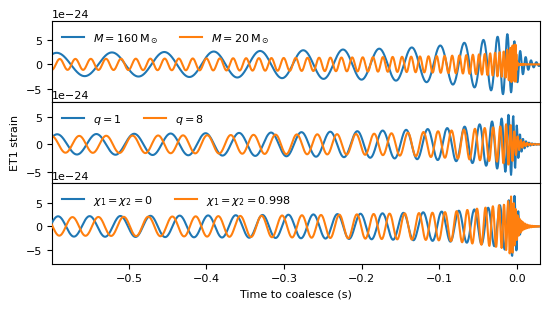

In [5]:
fig, axs = plt.subplots(nrows=3, figsize=(16/2.54, 8/2.54), sharex=True)
fig.subplots_adjust(hspace=0)

time = np.arange(sample_generator.td_length)*sample_generator.delta_t \
       - merger_time[0]*sample_generator.sample_length
mask = np.logical_and(-0.6 <= time, time < 0.03)
axs[0].set_xlim(time[mask][0], time[mask][-1])
axs[0].plot(time[mask], high_mass[mask], label=r"$M = 160\,\mathrm{M}_\odot$")
axs[0].plot(time[mask], low_mass[mask], label=r"$M = 20\,\mathrm{M}_\odot$")
axs[1].plot(time[mask], low_q[mask], label=r"$q = 1$")
axs[1].plot(time[mask], high_q[mask], label=r"$q = 8$")
axs[2].plot(time[mask], no_spin_no_spin[mask], label=r"$\chi_1 = \chi_2 = 0$", zorder=10)
# axs[2].plot(time[mask], spin_no_spin[mask], label=r"$\chi_1 = 0.998$, $\chi_2 = 0$", zorder=30)
axs[2].plot(time[mask], spin_spin[mask], label=r"$\chi_1 = \chi_2 = 0.998$", zorder=20)
for ax, factor in zip(axs, (1.3, 1.3, 1.3)):
    ylim = ax.get_ylim()
    ax.set_ylim((1+(factor-1)/2)*ylim[0], factor*ylim[1]) 
    ax.legend(frameon=False, ncol=3, loc=2)
axs[2].set_xlabel("Time to coalesce (s)")
axs[1].set_ylabel("ET1 strain")
fig.savefig("waveforms.png", dpi=300, bbox_inches="tight")